# Actividad 1. Ingesta, integración y depuración del conjunto de datos

## Objetivo
Realizar la ingesta, comprensión, integración y depuración del dataset OULAD con el propósito de construir un conjunto de datos consolidado, consistente y preparado para las etapas posteriores de transformación, ingeniería de características y modelado predictivo del riesgo académico.

## Relación con la metodología

Esta actividad corresponde al primer objetivo específico del Proyecto de Integración Curricular y se desarrolla principalmente sobre las fases **Data Understanding** y **Data Preparation** de las metodologías **CRISP-DM** y **CRISP-ML(Q)**.

Durante esta actividad se realizará la exploración inicial del dataset OULAD, la identificación de su estructura relacional, el análisis de la calidad de los datos, la integración de las tablas relevantes y los procedimientos de depuración necesarios para construir un conjunto de datos consistente que servirá como entrada para las siguientes etapas del proyecto.

# 2. Importación de librerías

Se importan las bibliotecas necesarias para la manipulación, análisis y visualización de datos durante la fase de comprensión del conjunto de datos.

In [51]:
# Librerías para manipulación de datos

import pandas as pd
import numpy as np


# Visualización
import matplotlib.pyplot as plt
import seaborn as sns


# Configuración general
pd.set_option("display.max_columns", None)

pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"]=(8,5)

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


# 3. Carga del dataset

El dataset OULAD está conformado por siete tablas relacionales que almacenan información académica, demográfica y de interacción de los estudiantes dentro del entorno virtual de aprendizaje.

En esta sección se cargan las siete tablas originales sin realizar modificaciones, preservando la integridad de los datos para las etapas posteriores del proyecto.

In [52]:
# Ruta del dataset

DATA_PATH="../data/raw/"

In [53]:
# Carga de las tablas

studentInfo = pd.read_csv(DATA_PATH+"studentInfo.csv")

studentAssessment = pd.read_csv(DATA_PATH+"studentAssessment.csv")

studentRegistration = pd.read_csv(DATA_PATH+"studentRegistration.csv")

studentVle = pd.read_csv(DATA_PATH+"studentVle.csv")

assessments = pd.read_csv(DATA_PATH+"assessments.csv")

courses = pd.read_csv(DATA_PATH+"courses.csv")

vle = pd.read_csv(DATA_PATH+"vle.csv")

In [54]:
print("Tablas cargadas correctamente.")

Tablas cargadas correctamente.


# 4. Verificación de la carga de datos

Se verifica que todas las tablas hayan sido cargadas correctamente mostrando sus dimensiones generales.

In [55]:
datasets={
    "studentInfo":studentInfo,
    "studentAssessment":studentAssessment,
    "studentRegistration":studentRegistration,
    "studentVle":studentVle,
    "assessments":assessments,
    "courses":courses,
    "vle":vle
}

summary=[]

for name,df in datasets.items():

    summary.append([
        name,
        df.shape[0],
        df.shape[1]
    ])

summary=pd.DataFrame(
    summary,
    columns=[
        "Tabla",
        "Registros",
        "Variables"
    ]
)

summary

,Tabla,Registros,Variables
0,studentInfo,32593,12
1,studentAssessment,173912,5
2,studentRegistration,32593,5
3,studentVle,10655280,6
4,assessments,206,6
5,courses,22,3
6,vle,6364,6


La tabla anterior permite verificar que las siete tablas del dataset fueron cargadas correctamente. Se observa que **studentVle** contiene el mayor número de registros debido a que almacena las interacciones realizadas por los estudiantes dentro del entorno virtual de aprendizaje, mientras que las demás tablas contienen información académica, demográfica y descriptiva de los cursos y recursos educativos.

# 5. Exploración general de las tablas

Con el objetivo de comprender la estructura del dataset, se realiza una exploración general de cada una de las tablas que conforman OULAD. Para cada tabla se analizarán:

- dimensiones;
- tipos de datos;
- valores faltantes;
- registros duplicados;
- uso de memoria;
- primeras observaciones.

Este análisis permite identificar posibles problemas de calidad de datos antes de iniciar la fase de preparación.

In [56]:
def explore_dataframe(df,name):

    print("="*90)

    print(f"TABLA: {name}")

    print("="*90)

    print(f"\nDimensiones: {df.shape}")

    print("\nPrimeras filas:")

    display(df.head())

    print("\nInformación general")

    df.info()

    print("\nValores faltantes")

    display(df.isnull().sum())

    print("\nDuplicados:",df.duplicated().sum())

    print("\nTipos de datos")

    display(df.dtypes)

    print("\nEstadísticas descriptivas")

    display(df.describe(include="all").T)

In [57]:
for name,df in datasets.items():

    explore_dataframe(df,name)

TABLA: studentInfo

Dimensiones: (32593, 12)

Primeras filas:


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass



Información general
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   code_module           32593 non-null  object
 1   code_presentation     32593 non-null  object
 2   id_student            32593 non-null  int64 
 3   gender                32593 non-null  object
 4   region                32593 non-null  object
 5   highest_education     32593 non-null  object
 6   imd_band              32593 non-null  object
 7   age_band              32593 non-null  object
 8   num_of_prev_attempts  32593 non-null  int64 
 9   studied_credits       32593 non-null  int64 
 10  disability            32593 non-null  object
 11  final_result          32593 non-null  object
dtypes: int64(3), object(9)
memory usage: 3.0+ MB

Valores faltantes


code_module             0
code_presentation       0
id_student              0
gender                  0
region                  0
highest_education       0
imd_band                0
age_band                0
num_of_prev_attempts    0
studied_credits         0
disability              0
final_result            0
dtype: int64


Duplicados: 0

Tipos de datos


...

id_site              0
code_module          0
code_presentation    0
activity_type        0
week_from            0
week_to              0
dtype: int64


Duplicados: 0

Tipos de datos


id_site               int64
code_module          object
code_presentation    object
activity_type        object
week_from            object
week_to              object
dtype: object


Estadísticas descriptivas


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id_site,6364.0,NaN,NaN,NaN,726099.094123,128315.137473,526721.0,661592.75,730096.5,814016.25,1077905.0
code_module,6364,7,FFF,1967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
code_presentation,6364,4,2013J,1772,NaN,NaN,NaN,NaN,NaN,NaN,NaN
activity_type,6364,20,resource,2660,NaN,NaN,NaN,NaN,NaN,NaN,NaN
week_from,6364,31,?,5243,NaN,NaN,NaN,NaN,NaN,NaN,NaN
week_to,6364,31,?,5243,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 6. Análisis de la estructura relacional del dataset OULAD

El dataset **Open University Learning Analytics Dataset (OULAD)** posee una estructura relacional compuesta por siete tablas interconectadas mediante diferentes identificadores. Antes de realizar cualquier proceso de integración, resulta necesario comprender cómo se relacionan dichas tablas y cuál es la información que aporta cada una al problema de investigación.

En esta sección se analiza la estructura lógica del dataset, identificando las llaves de relación y la finalidad de cada tabla. Este análisis permitirá justificar posteriormente la selección de las tablas que serán utilizadas para construir el conjunto de datos destinado a la predicción del riesgo académico.

Esta actividad forma parte de la fase **Data Understanding** de las metodologías **CRISP-DM** y **CRISP-ML(Q)**, ya que proporciona una comprensión integral de la organización de los datos antes de iniciar los procesos de preparación y transformación.

In [58]:
# Descripción general de las tablas del dataset OULAD

table_description = pd.DataFrame({

    "Tabla":[
        "studentInfo",
        "studentAssessment",
        "studentRegistration",
        "studentVle",
        "assessments",
        "courses",
        "vle"
    ],

    "Descripción":[
        "Información demográfica y resultado académico del estudiante.",
        "Calificaciones obtenidas por los estudiantes en las evaluaciones.",
        "Información de matrícula y fecha de inscripción de los estudiantes.",
        "Interacciones de los estudiantes con el entorno virtual de aprendizaje.",
        "Información de las evaluaciones de cada curso.",
        "Información general de módulos y presentaciones.",
        "Descripción de los recursos disponibles en el entorno virtual."
    ],

    "Llaves principales":[
        "id_student, code_module, code_presentation",
        "id_student, id_assessment",
        "id_student, code_module, code_presentation",
        "id_student, id_site",
        "id_assessment",
        "code_module, code_presentation",
        "id_site"
    ]

})

table_description

,Tabla,Descripción,Llaves principales
0,studentInfo,Información demográfica y resultado académico ...,"id_student, code_module, code_presentation"
1,studentAssessment,Calificaciones obtenidas por los estudiantes e...,"id_student, id_assessment"
2,studentRegistration,Información de matrícula y fecha de inscripció...,"id_student, code_module, code_presentation"
3,studentVle,Interacciones de los estudiantes con el entorn...,"id_student, id_site"
4,assessments,Información de las evaluaciones de cada curso.,id_assessment
5,courses,Información general de módulos y presentaciones.,"code_module, code_presentation"
6,vle,Descripción de los recursos disponibles en el ...,id_site


La tabla anterior resume el propósito de cada uno de los conjuntos de datos que conforman OULAD. Se observa que la información se encuentra distribuida en diferentes tablas especializadas, donde cada una aporta una perspectiva distinta del proceso de aprendizaje, incluyendo información demográfica, rendimiento académico, comportamiento dentro del entorno virtual y características propias de los cursos y evaluaciones.

Esta organización responde a un modelo de base de datos relacional, en el cual la información se vincula mediante identificadores compartidos entre las tablas.

In [59]:
# Variables compartidas entre las tablas


column_sets = {
    name: set(df.columns)
    for name, df in datasets.items()
}

relationships = []

tables = list(column_sets.keys())

for i in range(len(tables)):
    for j in range(i + 1, len(tables)):

        common = sorted(
            column_sets[tables[i]].intersection(column_sets[tables[j]])
        )

        if common:

            relationships.append({
                "Tabla 1": tables[i],
                "Tabla 2": tables[j],
                "Columnas compartidas": ", ".join(common)
            })

relationships = pd.DataFrame(relationships)

relationships

,Tabla 1,Tabla 2,Columnas compartidas
0,studentInfo,studentAssessment,id_student
1,studentInfo,studentRegistration,"code_module, code_presentation, id_student"
2,studentInfo,studentVle,"code_module, code_presentation, id_student"
3,studentInfo,assessments,"code_module, code_presentation"
4,studentInfo,courses,"code_module, code_presentation"
5,studentInfo,vle,"code_module, code_presentation"
6,studentAssessment,studentRegistration,id_student
7,studentAssessment,studentVle,id_student
8,studentAssessment,assessments,id_assessment
9,studentRegistration,studentVle,"code_module, code_presentation, id_student"


La identificación de columnas compartidas permite reconocer las posibles relaciones entre las tablas del dataset. Se observa que variables como **id_student**, **code_module**, **code_presentation** e **id_assessment** aparecen en múltiples conjuntos de datos, constituyendo las principales llaves de integración.

Estas relaciones serán utilizadas posteriormente para consolidar la información académica y de interacción en un único conjunto de datos orientado al desarrollo de modelos predictivos.

In [60]:
# Verificación de llaves de integración


keys = [
    "id_student",
    "code_module",
    "code_presentation",
    "id_assessment",
    "id_site"
]

verification = []

for name, df in datasets.items():

    verification.append({

        "Tabla": name,

        **{
            key: "Sí" if key in df.columns else "-"
            for key in keys
        }

    })

verification = pd.DataFrame(verification)

verification

,Tabla,id_student,code_module,code_presentation,id_assessment,id_site
0,studentInfo,Sí,Sí,Sí,-,-
1,studentAssessment,Sí,-,-,Sí,-
2,studentRegistration,Sí,Sí,Sí,-,-
3,studentVle,Sí,Sí,Sí,-,Sí
4,assessments,-,Sí,Sí,Sí,-
5,courses,-,Sí,Sí,-,-
6,vle,-,Sí,Sí,-,Sí


La verificación confirma que las tablas contienen los identificadores necesarios para establecer relaciones entre ellas. En particular, **id_student** constituye la llave principal para vincular la información correspondiente a cada estudiante, mientras que **code_module**, **code_presentation** e **id_assessment** permiten complementar la información relacionada con los cursos y las evaluaciones.

La presencia de estas llaves garantiza la viabilidad del proceso de integración que se desarrollará en las siguientes secciones del proyecto.

In [61]:
# Evaluación de las tablas para el proyecto

selection = pd.DataFrame({

    "Tabla":[
        "studentInfo",
        "studentAssessment",
        "studentRegistration",
        "studentVle",
        "assessments",
        "courses",
        "vle"
    ],

    "Se utilizará":[
        "Sí",
        "Sí",
        "No",
        "Sí",
        "Sí",
        "No",
        "No"
    ],

    "Justificación":[

        "Contiene las variables demográficas y la variable objetivo.",

        "Proporciona el historial de calificaciones de los estudiantes.",

        "Su información de matrícula no aporta variables relevantes para el objetivo predictivo.",

        "Describe el comportamiento e interacción del estudiante dentro del entorno virtual.",

        "Complementa la información de las evaluaciones realizadas por los estudiantes.",

        "Contiene únicamente información descriptiva de los cursos.",

        "Describe los recursos virtuales, sin aportar variables predictivas directas."

    ]

})

selection

,Tabla,Se utilizará,Justificación
0,studentInfo,Sí,Contiene las variables demográficas y la varia...
1,studentAssessment,Sí,Proporciona el historial de calificaciones de ...
2,studentRegistration,No,Su información de matrícula no aporta variable...
3,studentVle,Sí,Describe el comportamiento e interacción del e...
4,assessments,Sí,Complementa la información de las evaluaciones...
5,courses,No,Contiene únicamente información descriptiva de...
6,vle,No,"Describe los recursos virtuales, sin aportar v..."


El análisis realizado permite identificar que, aunque el dataset OULAD está conformado por siete tablas, no todas aportan información relevante para el objetivo de esta investigación.

Las tablas **studentInfo**, **studentAssessment**, **studentVle** y **assessments** contienen información directamente relacionada con las características demográficas, el rendimiento académico y el comportamiento de los estudiantes en el entorno virtual, aspectos ampliamente reportados en la literatura como factores asociados al riesgo académico.

Por el contrario, las tablas **studentRegistration**, **courses** y **vle** contienen información principalmente administrativa o descriptiva, cuyo aporte al objetivo específico de construir un modelo predictivo resulta limitado. Por esta razón, dichas tablas serán consideradas durante la fase de comprensión del dataset, pero no serán integradas en la construcción del conjunto de datos experimental.

Cabe resaltar que la tabla **StudentVle** debido a su naturaleza de datos transaccionales de alta granularidad, esta tabla no se integra directamente en el modelo base, sino que será procesada mediante técnicas de agregación y transformación en la Actividad 2 (Ingeniería de características), con el fin de generar variables representativas del comportamiento del estudiante.

# 7. Integración de las tablas seleccionadas

Con base en el análisis realizado en la sección anterior, se procede a integrar únicamente las tablas que aportan información relevante para el objetivo de la investigación. Estas corresponden a:

- **studentInfo:** información demográfica y resultado académico del estudiante.
- **studentAssessment:** calificaciones obtenidas por los estudiantes.
- **assessments:** características de las evaluaciones.
- **studentVle:** interacción de los estudiantes con el entorno virtual.

La integración se realiza de manera progresiva utilizando las llaves primarias y foráneas definidas en el dataset OULAD, preservando la integridad de la información y evitando modificaciones que alteren los datos originales.

Como resultado de esta sección se obtendrá un conjunto de datos consolidado que servirá como base para las etapas posteriores de depuración, transformación e ingeniería de características.

## 7.1 Creación de copias de trabajo

Para preservar la integridad de las tablas originales, se crean copias independientes que serán utilizadas durante el proceso de integración y depuración de los datos.

In [62]:
# Copias de trabajo


studentInfo_df = studentInfo.copy()

studentAssessment_df = studentAssessment.copy()

assessments_df = assessments.copy()

studentVle_df = studentVle.copy()

print("Copias de trabajo creadas correctamente.")

Copias de trabajo creadas correctamente.


Las copias de trabajo permiten mantener intactos los datos originales cargados desde el dataset OULAD. De esta manera, cualquier transformación o proceso de limpieza realizado durante el desarrollo del proyecto podrá reproducirse sin alterar las fuentes de información originales.

## 7.2 Integración de la información de evaluaciones

La primera integración consiste en combinar las tablas **studentAssessment** y **assessments**.

Esta unión permite complementar las calificaciones obtenidas por cada estudiante con las características propias de cada evaluación, como el tipo de actividad, la fecha de entrega y el peso asignado dentro del curso.

La integración se realiza mediante el identificador **id_assessment**, el cual constituye la llave de relación entre ambas tablas.

In [63]:
# Integración de evaluaciones


assessment_data = pd.merge(

    studentAssessment_df,

    assessments_df,

    on="id_assessment",

    how="left"

)

print("Dimensiones del dataset integrado:")

print(assessment_data.shape)

assessment_data.head()

Dimensiones del dataset integrado:
(173912, 10)


,id_assessment,id_student,date_submitted,is_banked,score,code_module,code_presentation,assessment_type,date,weight
0,1752,11391,18,0,78,AAA,2013J,TMA,19,10.0
1,1752,28400,22,0,70,AAA,2013J,TMA,19,10.0
2,1752,31604,17,0,72,AAA,2013J,TMA,19,10.0
3,1752,32885,26,0,69,AAA,2013J,TMA,19,10.0
4,1752,38053,19,0,79,AAA,2013J,TMA,19,10.0


El conjunto de datos obtenido integra la información correspondiente a las calificaciones de los estudiantes junto con las características de cada evaluación. Esta consolidación permitirá disponer de una visión más completa del desempeño académico durante las siguientes etapas del proyecto.

## 7.3 Verificación de la integración de evaluaciones

Una vez realizada la integración, es necesario comprobar que la unión entre ambas tablas se efectuó correctamente. Para ello se verifica la presencia de valores faltantes en las variables incorporadas desde la tabla **assessments**.

In [64]:
# Verificación del merge

assessment_data[
    [
        "assessment_type",
        "date",
        "weight"
    ]
].isnull().sum()

assessment_type    0
date               0
weight             0
dtype: int64

La ausencia de valores faltantes en las variables incorporadas confirma que la integración mediante el identificador **id_assessment** se realizó correctamente y que todas las evaluaciones poseen información asociada dentro del dataset original.

## 7.4 Integración de la información del estudiante

Posteriormente se incorpora la información demográfica y el resultado académico de cada estudiante utilizando la tabla **studentInfo**.

La integración se realiza mediante los identificadores **id_student**, **code_module** y **code_presentation**, garantizando la correspondencia entre cada estudiante y las evaluaciones pertenecientes al mismo módulo académico.

In [65]:
# Integración con studentInfo


student_data = pd.merge(

    studentInfo_df,

    assessment_data,

    on=[
        "id_student",
        "code_module",
        "code_presentation"
    ],

    how="left"

)

print("Dimensiones del dataset:")

print(student_data.shape)

student_data.head()

Dimensiones del dataset:
(180662, 19)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,id_assessment,date_submitted,is_banked,score,assessment_type,date,weight
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,1752.0,18.0,0.0,78,TMA,19,10.0
1,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,1753.0,53.0,0.0,85,TMA,54,20.0
2,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,1754.0,115.0,0.0,80,TMA,117,20.0
3,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,1755.0,164.0,0.0,85,TMA,166,20.0
4,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,1756.0,212.0,0.0,82,TMA,215,30.0


La integración incorpora al conjunto de datos la información demográfica y académica de cada estudiante junto con el historial de evaluaciones realizadas. Esto constituye una base más completa para caracterizar el desempeño académico de los estudiantes. Asimismo, se observa que el proceso de integración puede incrementar el número de registros debido a la naturaleza multievaluación del estudiante dentro del sistema académico, lo cual es consistente con la estructura del dataset OULAD.

## 7.5 Verificación de la integración del estudiante

Se verifica que las variables provenientes de las evaluaciones hayan sido incorporadas correctamente al conjunto de datos consolidado.

In [66]:
# Verificación del merge


student_data[
    [
        "score",
        "assessment_type",
        "weight"
    ]
].isnull().sum()

score              6750
assessment_type    6750
weight             6750
dtype: int64

Se identifican 6750 registros sin información asociada a evaluaciones académicas. Esta situación es consistente con la naturaleza del dataset OULAD, ya que algunos estudiantes no presentan actividades evaluativas registradas durante la presentación del módulo correspondiente. Estos casos serán analizados durante la fase de depuración para determinar el tratamiento más adecuado.

# 8. Verificación de la integridad referencial

Una vez realizada la integración inicial de las tablas seleccionadas, es necesario verificar que las relaciones entre ellas se hayan establecido correctamente.

En esta sección se comprueba que los registros asociados a estudiantes, módulos, presentaciones y evaluaciones mantengan consistencia dentro del conjunto de datos integrado.

Esta verificación constituye una etapa fundamental del aseguramiento de la calidad de los datos antes de iniciar los procesos de depuración.

In [67]:
# Variables clave que no deberían perderse

keys = [
    "id_student",
    "code_module",
    "code_presentation"
]

integrity = []

for key in keys:

    integrity.append({
        "Variable": key,
        "Valores nulos": student_data[key].isnull().sum(),
        "Valores únicos": student_data[key].nunique()
    })

integrity = pd.DataFrame(integrity)

integrity

,Variable,Valores nulos,Valores únicos
0,id_student,0,28785
1,code_module,0,7
2,code_presentation,0,4


In [68]:
print("Número total de registros:", len(student_data))

print("\nEstudiantes únicos:")

print(student_data["id_student"].nunique())

print("\nMódulos:")

print(student_data["code_module"].nunique())

print("\nPresentaciones:")

print(student_data["code_presentation"].nunique())

Número total de registros: 180662

Estudiantes únicos:
28785

Módulos:
7

Presentaciones:
4


In [69]:
student_data[
    keys
].isnull().sum()

id_student           0
code_module          0
code_presentation    0
dtype: int64

La verificación de integridad confirma que las variables utilizadas como llaves de integración (id_student, code_module y code_presentation) no presentan valores faltantes dentro del conjunto de datos consolidado. Esto garantiza la consistencia de las relaciones establecidas entre las tablas integradas y permite continuar con las etapas de depuración y preparación de los datos.

# 9. Evaluación de la calidad del conjunto de datos

Una vez verificada la integración de las tablas, se realiza una evaluación de la calidad del conjunto de datos obtenido.

El objetivo de esta sección es identificar posibles problemas que puedan afectar las etapas posteriores del proyecto, tales como valores faltantes, registros duplicados e inconsistencias en las variables.

Este análisis constituye una etapa fundamental dentro de la fase **Data Preparation** de las metodologías **CRISP-DM** y **CRISP-ML(Q)**.

## 9.1 Valores faltantes

In [70]:
missing = pd.DataFrame({

    "Valores faltantes": student_data.isnull().sum(),

    "Porcentaje (%)": round(
        student_data.isnull().mean()*100,
        2
    )

})

missing = missing.sort_values(
    by="Porcentaje (%)",
    ascending=False
)

missing

,Valores faltantes,Porcentaje (%)
assessment_type,6750,3.74
weight,6750,3.74
score,6750,3.74
date_submitted,6750,3.74
is_banked,6750,3.74
id_assessment,6750,3.74
date,6750,3.74
id_student,0,0.00
code_presentation,0,0.00
code_module,0,0.00


La evaluación de valores faltantes permite identificar aquellas variables que requieren un tratamiento específico antes de ser utilizadas durante la fase de modelado.

Se observa que las variables relacionadas con las evaluaciones presentan valores faltantes asociados principalmente a estudiantes que no registran actividades evaluativas, situación esperada dentro del contexto del dataset OULAD.

## 9.2 Registros duplicados

In [71]:
duplicates = student_data.duplicated().sum()

print(f"Registros duplicados: {duplicates}")

Registros duplicados: 0


La identificación de registros duplicados permite detectar posibles redundancias generadas durante el proceso de integración de las tablas.

La ausencia de registros duplicados indica que la consolidación inicial del conjunto de datos mantiene la consistencia de la información.

# 10. Detección de valores atípicos

Como parte del proceso de depuración del conjunto de datos, se analizan las principales variables numéricas mediante diagramas de caja (Boxplots).

El objetivo es identificar posibles valores atípicos que puedan representar errores de registro o comportamientos extremos presentes en la población estudiantil.

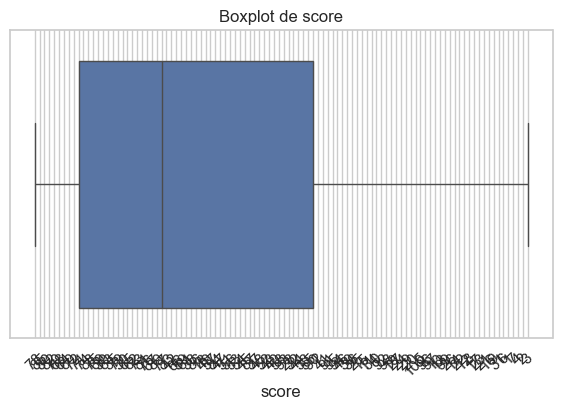

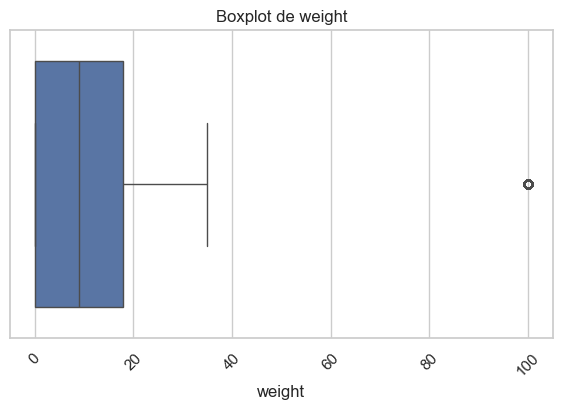

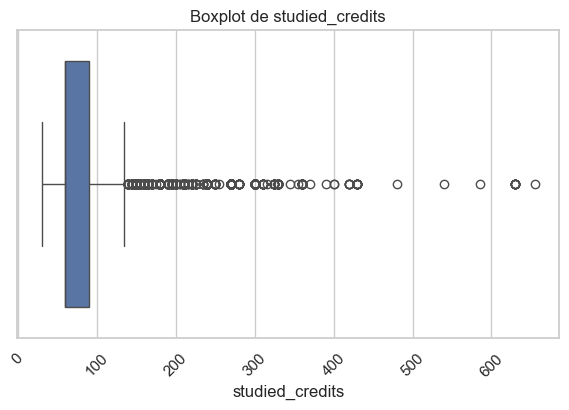

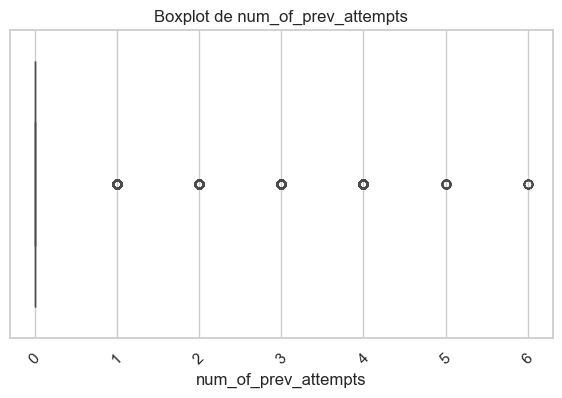

In [81]:
numeric_columns = [

    "score",

    "weight",

    "studied_credits",

    "num_of_prev_attempts"

]

for column in numeric_columns:

    plt.figure(figsize=(7,4))

    sns.boxplot(x=student_data[column])

    plt.title(f"Boxplot de {column}")
    plt.xlabel(column)

    plt.xticks(rotation=45)

    plt.show()

Los valores atípicos no fueron eliminados en esta etapa, ya que pueden representar variabilidad real del desempeño académico dentro del contexto del dataset OULAD.

Además, en problemas de clasificación de riesgo académico, la preservación de esta variabilidad permite mantener la representatividad del comportamiento estudiantil, evitando sesgos en las etapas posteriores de modelado.

# 11. Depuración del conjunto de datos

Con base en el análisis realizado anteriormente, se procede a efectuar la depuración inicial del conjunto de datos.

Las acciones realizadas incluyen el tratamiento de valores faltantes en variables categóricas y la eliminación de registros duplicados, preservando la información relevante para las siguientes etapas del proyecto.

## 11.1 Copia del dataset

In [73]:
student_data_clean = student_data.copy()

## 11.2 Tratamiento de variables categóricas con valores nulos

In [74]:
categorical_cols = ["imd_band", "region", "highest_education"]

for col in categorical_cols:
    student_data_clean[col] = student_data_clean[col].fillna("Unknown")

Se realizó la imputación de valores faltantes en variables categóricas utilizando la categoría ‘Unknown’, garantizando la preservación de la información sin introducir sesgos artificiales en la distribución de los datos

## 11.3 Eliminación de duplicados

In [75]:
print("Antes:", student_data_clean.shape)

student_data_clean = (

    student_data_clean

    .drop_duplicates()

)

print("Después:", student_data_clean.shape)

Antes: (180662, 19)
Después: (180662, 19)


## 11.4 Verificación

In [76]:
student_data_clean.isnull().sum()

code_module                0
code_presentation          0
id_student                 0
gender                     0
region                     0
highest_education          0
imd_band                   0
age_band                   0
num_of_prev_attempts       0
studied_credits            0
disability                 0
final_result               0
id_assessment           6750
date_submitted          6750
is_banked               6750
score                   6750
assessment_type         6750
date                    6750
weight                  6750
dtype: int64

Después del proceso de depuración se mantiene la integridad del conjunto de datos, corrigiendo únicamente aquellas inconsistencias que no alteran el comportamiento real de la información.

Los valores faltantes asociados a las variables de evaluación se conservan debido a que representan estudiantes sin registros de actividades evaluativas y no errores de captura.

# 12. Exportación del conjunto de datos depurado

Finalmente, el conjunto de datos obtenido se almacena en la carpeta **data/interim**, permitiendo mantener una trazabilidad clara entre los datos originales y los datos preparados para la siguiente actividad del proyecto.

In [77]:
OUTPUT_DIR = "../data/interim/"
OUTPUT_FILE = "student_data_clean.csv"

student_data_clean.to_csv(OUTPUT_DIR + OUTPUT_FILE, index=False)

print("Dataset exportado correctamente:", OUTPUT_DIR + OUTPUT_FILE)

Dataset exportado correctamente: ../data/interim/student_data_clean.csv


El archivo generado constituye el entregable principal de la Actividad 1 y será utilizado como punto de partida para la fase de transformación e ingeniería de características.

# 13. Conclusiones de la Actividad 1

En esta actividad se llevó a cabo la ingesta, comprensión, integración y depuración inicial del dataset OULAD, enmarcada principalmente en las fases de Data Understanding y Data Preparation de las metodologías CRISP-DM y CRISP-ML(Q), siguiendo un enfoque iterativo propio de los procesos de ciencia de datos.

Se analizaron las siete tablas que conforman el conjunto de datos, identificando su estructura relacional y justificando la selección de aquellas que aportan información relevante para el objetivo del proyecto. Posteriormente, se integraron las tablas relacionadas con la información demográfica de los estudiantes y sus evaluaciones académicas, garantizando la consistencia e integridad referencial del conjunto de datos consolidado.

Asimismo, se realizó una evaluación de la calidad de los datos mediante el análisis de valores faltantes, registros duplicados y posibles valores atípicos, aplicando un proceso de depuración inicial que preserva la representatividad de la información educativa.

Como resultado, se obtuvo un conjunto de datos consolidado, depurado y estructurado, listo para las siguientes etapas del pipeline de Machine Learning.